# SVm Kernel Indepth Intution and Implementation 

In [29]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 

In [30]:
x = np.linspace(-5.0, -5.0, 100) 
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x]) 

In [31]:
y 

array([ 8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66025404,
        8.66025404,  8.66025404,  8.66025404,  8.66025404,  8.66

In [32]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1]) 

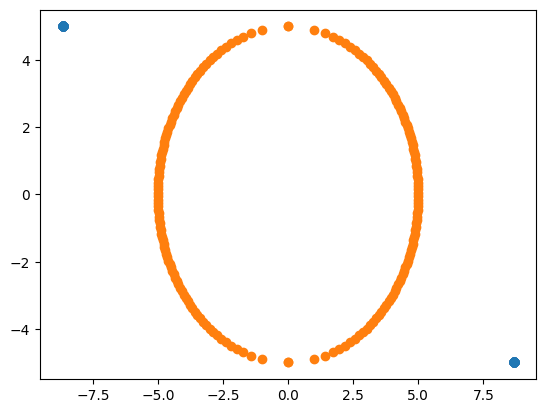

In [33]:
plt.scatter(y,x) 
plt.scatter(y1, x1) 

In [34]:
np.vstack([y,x]).T 

array([[ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404, -5.        ],
       [ 8.66025404,

In [35]:
import numpy as np
import pandas as pd

df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0

df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1

df = pd.concat([df1, df2], ignore_index=True)

df.head() 

,X1,X2,Y
0,8.660254,-5.0,0
1,8.660254,-5.0,0
2,8.660254,-5.0,0
3,8.660254,-5.0,0
4,8.660254,-5.0,0


In [36]:
df.tail() 

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [37]:
df = pd.concat([df1, df2], ignore_index=True) 
df 

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.660254,-5.00000,0
2,8.660254,-5.00000,0
3,8.660254,-5.00000,0
4,8.660254,-5.00000,0
...,...,...,...
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1


In [38]:
x = df.iloc[:, :2]  
y = df.Y  

In [39]:
y 

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0) 

In [41]:
y_train 

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

# Polynomial Kernel 

In [48]:
df['X1_Square'] = df['X1']**2 
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head() 

,X1,X2,Y,X1_square,X2_Square,X1*X2,X1_Square
0,8.660254,-5.0,0,75.0,25.0,-43.30127,75.0
1,8.660254,-5.0,0,75.0,25.0,-43.30127,75.0
2,8.660254,-5.0,0,75.0,25.0,-43.30127,75.0
3,8.660254,-5.0,0,75.0,25.0,-43.30127,75.0
4,8.660254,-5.0,0,75.0,25.0,-43.30127,75.0


In [49]:
# Independent and Dependent Features 
x  = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y'] 

In [50]:
y 

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 0)
 

In [52]:
x_train 

,X1,X2
250,4.999745,0.050505
63,8.660254,-5.000000
312,-3.263736,3.787879
159,-8.660254,5.000000
283,3.680983,3.383838
...,...,...
323,-4.223140,2.676768
192,-8.660254,5.000000
117,-8.660254,5.000000
47,8.660254,-5.000000


In [54]:
import plotly.express as px 
fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
              color='Y')
fig.show() 

In [57]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='X1_Square',
    y='X2_Square',
    z='X1*X2',
    color='Y'
)

fig.show() 

In [58]:
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred) 

0.45

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred) 

0.45

In [60]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred) 

1.0

In [61]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred) 

0.45